# The Perceptron: A Probabilistic Model for Information Storage and Organization

Replication of Rosenblatt (1958), *The Perceptron: A Probabilistic Model for Information
Storage and Organization in the Brain*, Psychological Review 65(6).

We implement the perceptron learning rule from scratch and train it on a linearly separable
two-class dataset. The paper's central guarantee, formalized later as the perceptron
convergence theorem, is that the rule makes a finite number of mistakes and converges to a
separating hyperplane whenever the data are linearly separable. We reproduce that
convergence and visualize the learned decision boundary.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

In [2]:
# Two linearly separable Gaussian blobs in 2D, labels in {-1, +1}.
n = 100
X = np.vstack([rng.normal([-2, -2], 0.8, (n, 2)), rng.normal([2, 2], 0.8, (n, 2))])
y = np.hstack([-np.ones(n), np.ones(n)])
print("data:", X.shape, "classes:", np.unique(y))

data: (200, 2) classes: [-1.  1.]


In [3]:
# Perceptron learning rule: on a misclassified point, w <- w + y*x (bias via augmented x).
def train_perceptron(X, y, epochs=20):
    Xa = np.hstack([X, np.ones((len(X), 1))])      # augment with bias term
    w = np.zeros(Xa.shape[1])
    mistakes_per_epoch = []
    for _ in range(epochs):
        mistakes = 0
        for xi, yi in zip(Xa, y):
            if yi * (w @ xi) <= 0:                  # misclassified
                w += yi * xi
                mistakes += 1
        mistakes_per_epoch.append(mistakes)
        if mistakes == 0:
            break
    return w, mistakes_per_epoch

w, hist = train_perceptron(X, y)
print("mistakes per epoch:", hist)
print("converged after", len(hist), "epochs with 0 mistakes")

mistakes per epoch: [1, 0]
converged after 2 epochs with 0 mistakes


In [4]:
pred = np.sign(np.hstack([X, np.ones((len(X), 1))]) @ w)
acc = (pred == y).mean()
print(f"training accuracy: {acc*100:.1f}%  (perceptron convergence theorem: 0 errors when separable)")

training accuracy: 100.0%  (perceptron convergence theorem: 0 errors when separable)


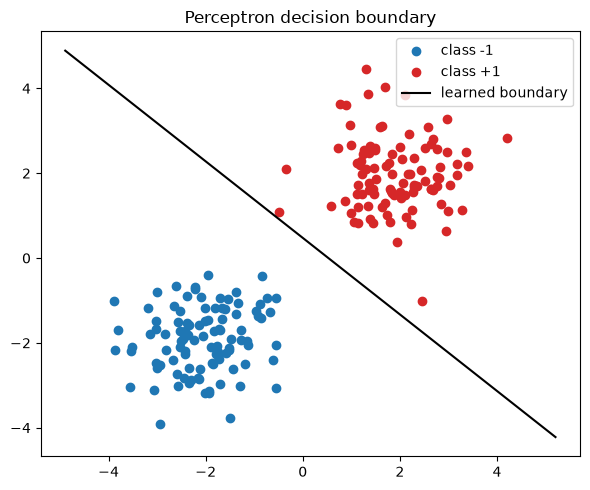

In [5]:
# Decision boundary w0*x + w1*y + b = 0.
xs = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
ys = -(w[0]*xs + w[2]) / w[1]
plt.figure(figsize=(6, 5))
plt.scatter(X[y==-1,0], X[y==-1,1], c="tab:blue", label="class -1")
plt.scatter(X[y==1,0],  X[y==1,1],  c="tab:red",  label="class +1")
plt.plot(xs, ys, "k-", label="learned boundary")
plt.legend(); plt.title("Perceptron decision boundary"); plt.tight_layout(); plt.show()